<h1><font color="#113D68" size=5>Redes neuronales y deep learning</font></h1>



<h1><font color="#113D68" size=6>Actividad Semana 3</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 3: Ajuste de modelos de Deep Learning</font><br>
<font size=3>IEBS</font>
</div>

---


<h3>Alumno: Adrián Robles Arques</h3>

In [98]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, InputLayer
from sklearn.model_selection import train_test_split


# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True' #Esta no es la solución optima, pero es la más rápida para evitar el error de duplicación de librerías de Anaconda
# En el propio mensaje de error indica que esta no es la mejor solución, puede arreglarse buscando la ubicación del fichero y eliminando la duplicación de librerías.
# Hecho

En esta actividad vamos a abordar un problema desde 0 al igual que hemos visto en las clases de esta semana, para ello vamos a utilizar un nuevo dataset donde tendréis que realizar todos los pasos vistos en clase para ajustar un modelo vosotros mismos.

**Destacar** que en la actividad de esta semana nos centraremos en encontrar la mejor arquitectura de red para el dataset que tenemos y en el caso práctico nos centraremos en realizar más experimentos jugando con el tamaño del batch, el valor del learning rate y el uso de capas dropout.

# <font color="#004D7F" size=5>Ejercicio</font>
En este notebook vamos a usar un dataset nuevo, el dataset es muy parecido al dataset del precio de las casas de boston. Esta vez vamos a utilizar un conjunto de datos que contienen información sobre el precio de las casas encontradas en un distrito de California. Las columnas son las siguientes:

- _longitude_: cuanto de al oeste está una casa; un valor más alto está más al oeste.
- _latitude_: cuanto de al norte está una casa; un valor más alto está más al norte.
- _housing_median_age_: edad media de una casa; un valor bajo es una casa más nueva.
- _total_rooms_: número total de habitaciones.
- _total_bedrooms_: número total de dormitorios.
- _population_: número total de personas que residen.
- _households_: número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda.
- _median_income_: ingreso medio de los hogares dentro de un bloque de casas (medido en decenas de miles de dólares).
- _ocean_proximity_: ubicación de la casa cerca del océano o mar.
- _median_house_value (**variables a predecir**)_: valor medio de la vivienda (medido en dólares).

Vamos a cargar los datos desde el fichero `housing.csv`:

In [81]:
df = pd.read_csv('housing.csv')

In [82]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3,342200.0


In [83]:
df.shape

(20433, 10)

Vamos a separar la variable objetivo del resto de variables (accedemos al campo value para que los datos sean de tipo _numpy array_ y se puedan usar como variable de entrada de nuestra red):

In [84]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

In [85]:
x = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity']].values
y = df[['median_house_value']].values

## 1. Establecer una función de coste adecuada a nuestro problema.

En este caso, como es un problema de regresión y los valores de nuestros datos son tan grandes, elegimos la función de coste `mean_absolute_percentage_error`, este error varía entre los valores 100 y 0 donde 100 es el pero error que podemos llegar a tener y 0 es el mejor error, por lo que en nuestros entrenamientos buscaremos un error más cercano a 0.

In [86]:
actual_loss = 'mean_absolute_percentage_error'

## 2. Elegir una estructura de red base

Ahora, como ya hemos visto en clase vamos a encontrar una estructura de red que encaje con los datos que vamos a utilizar. Vamos a crear varias redes a ver que tal funcionan.

Para hacer entrenamientos rápidos y ver si la red se adapta a los datos vamos a usar solo un subconjunto de los datos, es decir usaremos 1000 datos y no usaremos conjunto de validación. 

## <font color="#004D7F" size=4>Ejercicio 1</font>

Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [87]:
# Vamos a tomar 1000 muestras aleatoriamente para el entrenamiento rápido

# Creamos una lista de 1000 números aleatorios entre 0 y el número de filas del DataFrame
np.random.seed(42) #Ajustamos la semilla para que sea reproducible
random_index = np.random.randint(0, len(df), 1000)

# Creamos un nuevo dataframe con las filas aleatorias
x_ftrain = df.iloc[random_index, :-1].copy()  # Excluimos la última columna (median_house_value) para x_train
y_ftrain = df.iloc[random_index, -1].copy()   # Seleccionamos solo la última columna para y_train

In [88]:
x_ftrain.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
15795,-122.43,37.73,52.0,3602.0,738.0,2270.0,647.0,3.8934,3
860,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,3
5390,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,0
11964,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,0
11284,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,0


In [89]:
# Creamos la arquitectura de la red neuronal
model = Sequential()
model.add(InputLayer(input_shape=9))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation=None))

model.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_55 (Dense)             (None, 8)                 80        
_________________________________________________________________
dense_56 (Dense)             (None, 8)                 72        
_________________________________________________________________
dense_57 (Dense)             (None, 1)                 9         
Total params: 161
Trainable params: 161
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 0s 267us/step - loss: 100.2370
Epoch 2/30
32/32 [==============================] - 0s 259us/step - loss: 99.9682
Epoch 3/30
32/32 [==============================] - 0s 266us/step - loss: 99.6427
Epoch 4/30
32/32 [==============================] - 0s 271us/step - loss: 99.1430
Epoch 5/30
32/32 [==============================] - 0s 266us/step - loss: 98.3874
Epoch 6/30
32/32 [==============================] - 0s 247us/step - loss: 97.3176
Epoch 7/30
32/32 [==============================] - 0s 254us/step - loss: 95.9866
Epoch 8/30
32/32 [==============================] - 0s 276us/step - loss: 94.3227
Epoch 9/30
32/32 [==============================] - 0s 257us/step - loss: 92.1997
Epoch 10/30
32/32 [==============================] - 0s 269us/step - loss: 89.6273
Epoch 11/30
32/32 [==============================] - 0s 249us/step - loss: 86.4975
Epoch 12/30
32/32 [==============================] - 0s 266us/step - loss: 82.5652
Epoch 13/30


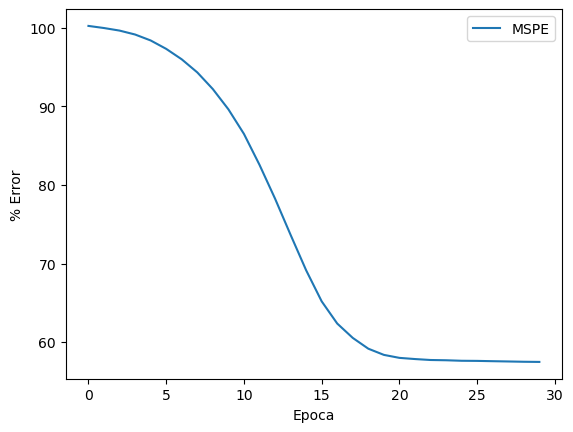

In [90]:
# Compilamos el modelo
model.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history = model.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

## <font color="#004D7F" size=4>Ejercicio 2</font>

Vamos a complicar un poco más la arquitectura de la red:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *5º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [91]:
# Creamos la arquitectura de la red neuronal
model2 = Sequential()
model2.add(InputLayer(input_shape=9))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1))

model2.summary()


Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_58 (Dense)             (None, 64)                640       
_________________________________________________________________
dense_59 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_60 (Dense)             (None, 32)                1056      
_________________________________________________________________
dense_61 (Dense)             (None, 1)                 33        
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 0s 300us/step - loss: 99.4130
Epoch 2/30
32/32 [==============================] - 0s 280us/step - loss: 97.0036
Epoch 3/30
32/32 [==============================] - 0s 283us/step - loss: 89.4983
Epoch 4/30
32/32 [==============================] - 0s 284us/step - loss: 71.0671
Epoch 5/30
32/32 [==============================] - 0s 295us/step - loss: 58.2316
Epoch 6/30
32/32 [==============================] - 0s 285us/step - loss: 58.6008
Epoch 7/30
32/32 [==============================] - 0s 291us/step - loss: 57.8073
Epoch 8/30
32/32 [==============================] - 0s 278us/step - loss: 57.7682
Epoch 9/30
32/32 [==============================] - 0s 281us/step - loss: 57.6599
Epoch 10/30
32/32 [==============================] - 0s 282us/step - loss: 57.3058
Epoch 11/30
32/32 [==============================] - 0s 276us/step - loss: 57.1565
Epoch 12/30
32/32 [==============================] - 0s 276us/step - loss: 57.0691
Epoch 13/30
3

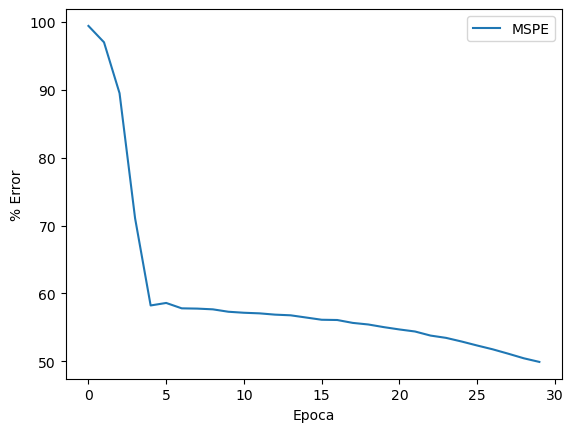

In [92]:
# Compilamos el modelo
model2.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history2 = model2.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history2.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

## <font color="#004D7F" size=4>Ejercicio 3</font>

Vamos a complicar aun más la arquitectura de la red:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *5º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *6º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [93]:
# Creamos la arquitectura de la red neuronal
model3 = Sequential()
model3.add(InputLayer(input_shape=9))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1))

model3.summary()

Model: "sequential_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_62 (Dense)             (None, 128)               1280      
_________________________________________________________________
dense_63 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_64 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_65 (Dense)             (None, 16)                528       
_________________________________________________________________
dense_66 (Dense)             (None, 1)                 17        
Total params: 12,161
Trainable params: 12,161
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 0s 316us/step - loss: 99.1522
Epoch 2/30
32/32 [==============================] - 0s 327us/step - loss: 94.5704
Epoch 3/30
32/32 [==============================] - 0s 307us/step - loss: 69.8922
Epoch 4/30
32/32 [==============================] - 0s 308us/step - loss: 58.5644
Epoch 5/30
32/32 [==============================] - 0s 304us/step - loss: 57.4746
Epoch 6/30
32/32 [==============================] - 0s 306us/step - loss: 57.4594
Epoch 7/30
32/32 [==============================] - 0s 313us/step - loss: 56.7898
Epoch 8/30
32/32 [==============================] - 0s 315us/step - loss: 56.3064
Epoch 9/30
32/32 [==============================] - 0s 316us/step - loss: 55.9354
Epoch 10/30
32/32 [==============================] - 0s 312us/step - loss: 55.4312
Epoch 11/30
32/32 [==============================] - 0s 307us/step - loss: 54.7699
Epoch 12/30
32/32 [==============================] - 0s 312us/step - loss: 54.0061
Epoch 13/30
3

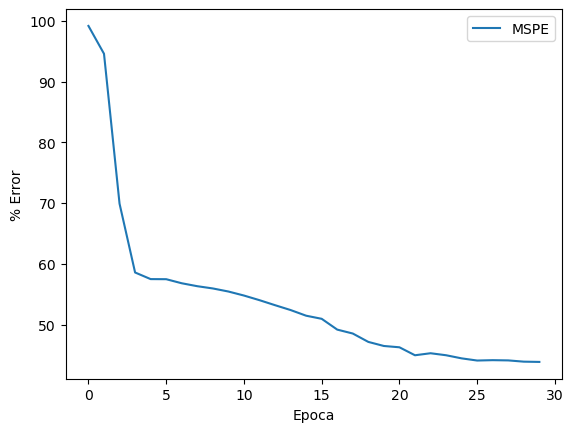

In [94]:
# Compilamos el modelo
model3.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history3 = model3.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history3.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

## <font color="#004D7F" size=4>Ejercicio 4</font>

Vamos a hacer una última red con más capas y neuronas:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 1024 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 512 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 256 neuronas y función de activación *relu*.
        - *5º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *6º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *7º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *8º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *9º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [95]:
# Creamos la arquitectura de la red neuronal
model4 = Sequential()
model4.add(InputLayer(input_shape=9))
for i in range(7):
    model4.add(Dense(8*2**(7-i), activation='relu'))
model4.add(Dense(1))

model4.summary()

Model: "sequential_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_67 (Dense)             (None, 1024)              10240     
_________________________________________________________________
dense_68 (Dense)             (None, 512)               524800    
_________________________________________________________________
dense_69 (Dense)             (None, 256)               131328    
_________________________________________________________________
dense_70 (Dense)             (None, 128)               32896     
_________________________________________________________________
dense_71 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_72 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_73 (Dense)             (None, 16)              

Epoch 1/30
32/32 [==============================] - 0s 2ms/step - loss: 81.8863
Epoch 2/30
32/32 [==============================] - 0s 2ms/step - loss: 58.2065
Epoch 3/30
32/32 [==============================] - 0s 2ms/step - loss: 56.7799
Epoch 4/30
32/32 [==============================] - 0s 2ms/step - loss: 55.7075
Epoch 5/30
32/32 [==============================] - 0s 2ms/step - loss: 51.8558
Epoch 6/30
32/32 [==============================] - 0s 2ms/step - loss: 48.9315
Epoch 7/30
32/32 [==============================] - 0s 2ms/step - loss: 46.5091
Epoch 8/30
32/32 [==============================] - 0s 2ms/step - loss: 46.4304
Epoch 9/30
32/32 [==============================] - 0s 2ms/step - loss: 45.5345
Epoch 10/30
32/32 [==============================] - 0s 2ms/step - loss: 43.9856
Epoch 11/30
32/32 [==============================] - 0s 2ms/step - loss: 44.4566
Epoch 12/30
32/32 [==============================] - 0s 2ms/step - loss: 44.2377
Epoch 13/30
32/32 [==================

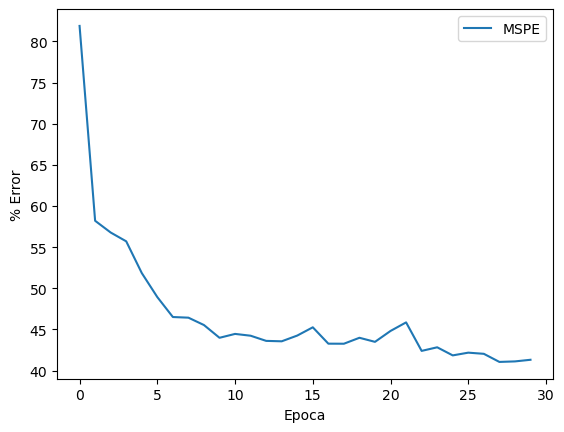

In [96]:
# Compilamos el modelo
model4.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history4 = model4.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history4.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

## <font color="#004D7F" size=4>Ejercicio 5</font>
Compara los resultados obtenidos en cada una de las arquitecturas definidas y quédate con la mejor. **¿En qué experimento se obtiene los mejores resultados?**

La arquitectura elegida la usaremos en el caso práctico para seguir ajustando nuestro modelo y alcanzar un buen rendimiento.

De acuerdo con los resultados y gráficos para cada modelo, aunque el valor mínimo que se alcanza en la función de error para el cuarto modelo es ligeramente inferior, considero que el segundo modelo es el indicado para la solución del problema. Mi alternativa más cercana sería el tercero, ya que tiene un valor mínimo de la función de pérdida con escasas fluctuaciones, pero a la larga se observa mayor error en la función de error para el conjunto de validación, como se puede observar en las ambas gráficas que aparecen a continuación. El modelo elegido es suficientemente complejo para este problema, y no tan complejo como para introducir errores artificiales, además de ahorrar en costes y tiempo de entrenamiento, gracias a sus poco más de 3000 parámetros configurables, frente a los más de 12000 del tercermodelo, o más de 710000 del último. El primero, por su parte, sería demasiado simple y poco eficiente puesto que tardaría mucho en converger a una solución, si es que lo logra.

In [124]:
# Creamos la arquitectura de la red neuronal
modelf = Sequential()
modelf.add(InputLayer(input_shape=9))
modelf.add(Dense(128, activation='relu'))
modelf.add(Dense(64, activation='relu'))
modelf.add(Dense(32, activation='relu'))
modelf.add(Dense(16, activation='relu'))
modelf.add(Dense(1))

modelf.summary()


Model: "sequential_22"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_100 (Dense)            (None, 128)               1280      
_________________________________________________________________
dense_101 (Dense)            (None, 64)                8256      
_________________________________________________________________
dense_102 (Dense)            (None, 32)                2080      
_________________________________________________________________
dense_103 (Dense)            (None, 16)                528       
_________________________________________________________________
dense_104 (Dense)            (None, 1)                 17        
Total params: 12,161
Trainable params: 12,161
Non-trainable params: 0
_________________________________________________________________


In [126]:
# Preparamos early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

Epoch 1/200
164/164 [==============================] - 0s 742us/step - loss: 72.4685 - val_loss: 55.5505
Epoch 2/200
164/164 [==============================] - 0s 463us/step - loss: 52.9389 - val_loss: 52.0142
Epoch 3/200
164/164 [==============================] - 0s 459us/step - loss: 46.0660 - val_loss: 48.1603
Epoch 4/200
164/164 [==============================] - 0s 461us/step - loss: 42.3779 - val_loss: 47.5161
Epoch 5/200
164/164 [==============================] - 0s 455us/step - loss: 41.8786 - val_loss: 47.3479
Epoch 6/200
164/164 [==============================] - 0s 461us/step - loss: 41.4210 - val_loss: 46.9025
Epoch 7/200
164/164 [==============================] - 0s 457us/step - loss: 41.0873 - val_loss: 46.9221
Epoch 8/200
164/164 [==============================] - 0s 456us/step - loss: 40.5392 - val_loss: 45.8377
Epoch 9/200
164/164 [==============================] - 0s 461us/step - loss: 39.8859 - val_loss: 45.2178
Epoch 10/200
164/164 [==============================] -

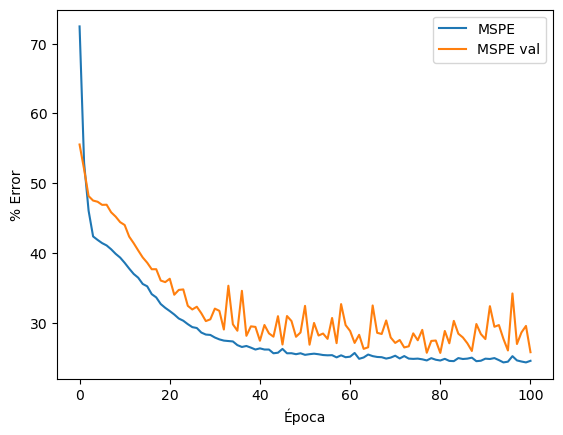

In [127]:
# Compilamos el modelo
modelf.compile(loss= actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
historyf = modelf.fit(x, y, epochs=200, batch_size=100,
                    verbose=1, validation_split=0.2,
                    callbacks=[early_stopping])

# Graficamos la evolución de la función de pérdida
plt.plot(historyf.history['loss'], label='MSPE')
plt.plot(historyf.history['val_loss'], label='MSPE val')
plt.ylabel('% Error')
plt.xlabel('Época')
plt.legend()
plt.show()

In [128]:
# Creamos la arquitectura de la red neuronal
modelf2 = Sequential()
modelf2.add(InputLayer(input_shape=9))
modelf2.add(Dense(64, activation='relu'))
modelf2.add(Dense(32, activation='relu'))
modelf2.add(Dense(32, activation='relu'))
modelf2.add(Dense(1))

modelf2.summary()

Model: "sequential_23"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_105 (Dense)            (None, 64)                640       
_________________________________________________________________
dense_106 (Dense)            (None, 32)                2080      
_________________________________________________________________
dense_107 (Dense)            (None, 32)                1056      
_________________________________________________________________
dense_108 (Dense)            (None, 1)                 33        
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________


Epoch 1/200
164/164 [==============================] - 0s 672us/step - loss: 82.3279 - val_loss: 56.0329
Epoch 2/200
164/164 [==============================] - 0s 408us/step - loss: 54.9130 - val_loss: 54.9877
Epoch 3/200
164/164 [==============================] - 0s 402us/step - loss: 53.2103 - val_loss: 53.4986
Epoch 4/200
164/164 [==============================] - 0s 391us/step - loss: 49.6389 - val_loss: 50.1510
Epoch 5/200
164/164 [==============================] - 0s 405us/step - loss: 44.4476 - val_loss: 47.9078
Epoch 6/200
164/164 [==============================] - 0s 402us/step - loss: 42.5601 - val_loss: 48.3810
Epoch 7/200
164/164 [==============================] - 0s 389us/step - loss: 42.1403 - val_loss: 47.6955
Epoch 8/200
164/164 [==============================] - 0s 374us/step - loss: 41.8477 - val_loss: 47.3666
Epoch 9/200
164/164 [==============================] - 0s 376us/step - loss: 41.6353 - val_loss: 47.7330
Epoch 10/200
164/164 [==============================] -

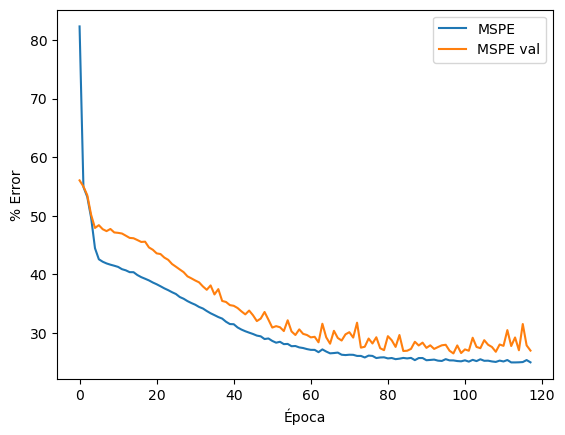

In [129]:
# Compilamos el modelo
modelf2.compile(loss= actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
historyf2 = modelf2.fit(x, y, epochs=200, batch_size=100,
                    verbose=1, validation_split=0.2,
                    callbacks=[early_stopping])

# Graficamos la evolución de la función de pérdida
plt.plot(historyf2.history['loss'], label='MSPE')
plt.plot(historyf2.history['val_loss'], label='MSPE val')
plt.ylabel('% Error')
plt.xlabel('Época')
plt.legend()
plt.show()

Comparando ambas gráficas, podemos observar que el error en validación es prácticamente idéntico, con menos saltos en segundo modelo con respecto al tercer modelo (que es el primero implementado, para comparativa). Si bien la gráfica parece sugerir que incluso un modelo algo más simple que éste último también podría ser suficiente.